**Agenda**
- **PART 1 — Why Decision Trees Matter**
- **PART 2 — Tree Structure & Terminology**
- **PART 3 — Recursive Splitting**
- **PART 4 — Impurity Measures**
- **PART 5 — Gini Impurity**
- **PART 6 — Entropy & Information Gain**
- **PART 7 — Complete Numerical Example**
- **PART 8 — Stopping Criteria**
- **PART 9 — Gini vs Entropy**
- **PART 10 — Practical Implementation**

https://stats.stackexchange.com/questions/87182/what-is-the-role-of-the-logarithm-in-shannons-entropy

https://www.bogotobogo.com/python/scikit-learn/scikt_machine_learning_Decision_Tree_Learning_Informatioin_Gain_IG_Impurity_Entropy_Gini_Classification_Error.php

https://www.listendata.com/2015/03/difference-between-chaid-and-cart.html

https://hitechnectar.com/blogs/hyperparameter-vs-parameter/

https://ml.kanaries.net/playground/decision-tree?utm_source=chatgpt.com

# **PART 1 — Why Decision Trees Matter**

**What is a Decision Tree?**

- A Decision Tree is a supervised learning algorithm that learns a sequence of decision rules to make predictions.

**Instead of learning a mathematical equation:**

$$y = mx + b$$

**a decision tree learns:**

- IF condition A
    - THEN go left

ELSE
    - go right
- Human Decision Making Analogy

Suppose you want to decide whether to buy a laptop.

**Your reasoning may look like:**

![image](attachment:b0f1262c-0664-4d5c-9342-67d0b3e0f454.png)

- This is exactly how a decision tree works.

**Interview One-Liner**

- Decision Trees mimic human decision-making using hierarchical rules.


**Why Trees Are Powerful**

- Unlike linear models:

$$y = wx + b$$

**Trees naturally capture:**

- Non-linearity
- Feature interactions
- Threshold-based decisions

**Example**

- Linear Model:

  - Age affects salary linearly

Decision Tree:

Much more flexible.

**Advantages of Decision Trees**

- Interpretability

  - Easy to explain.
  - Minimal Preprocessing

**No need for:**
- Feature scaling
- Normalization
- Standardization
- Mixed Data Types


**Can handle:**
- Numerical features
- Categorical features
- Non-Linear Relationships

Naturally captures complex decision boundaries.

# **PART 2 — Tree Structure & Terminology**

**Components of a Tree**

- A decision tree consists of:

In [ ]:
print("""
        Root
       /    \\
      /      \\
 Decision   Decision
    |           |
  Leaf       Leaf
""")


        Root
       /    \
      /      \
 Decision   Decision
    |           |
  Leaf       Leaf



## Root Node

The **top-most node** of the decision tree.

**Contains:**
- The entire dataset before any splitting occurs.

The first decision is made at the root node.

**Example:**
- `Age > 30?`

Based on the answer, the data is divided into different branches.

---

## Decision Node

A **node where the data is split** based on a condition or rule.

**Example:**
- `Income > 50K?`

Depending on the answer, the data moves to another decision node or to a leaf node.

---

## Leaf Node

The **final node** of a decision tree where the prediction is made.

**Example:**
- `Approved`
- `Rejected`

No further splitting occurs after reaching a leaf node.

---

## Branch

A **connection between two nodes**.

It represents the outcome of a decision or condition.

**Examples:**
- `True / False`
- `Yes / No`
- `Age > 30 / Age ≤ 30`

Branches guide the data from one node to the next.

---

## Tree Depth

The **longest path from the root node to a leaf node**.

**Example:**
- `Depth = 3`

This means the longest path contains **three levels of decision-making**.

---

## Why Tree Depth Matters

### Shallow Tree

- Has fewer decision levels.
- Simpler and easier to understand.
- Usually has a **lower risk of overfitting**.
- May sometimes **underfit** if it is too simple.

### Deep Tree

- Has more decision levels.
- Can capture more complex patterns in the data.
- More expressive and flexible.
- Has a **higher risk of overfitting**.

# **PART 3 — Recursive Splitting**

## Core Learning Mechanism

Decision Trees learn through **Recursive Partitioning**.

This means the dataset is repeatedly divided into smaller subsets based on different conditions.

At each step, the algorithm tries to separate the data in a way that makes the resulting groups as **pure as possible**.

For example, a dataset may first be split based on:

- `Age > 30?`

Then each resulting subset can be split again using another condition.

---

## Training Algorithm

### Step 1: Evaluate Every Feature

The algorithm examines all available features that could be used for splitting the data.

**Example:**
- Age
- Income
- Experience

---

### Step 2: Evaluate Every Possible Split

For each feature, the algorithm checks different possible split conditions.

**Example:**

For the feature `Age`, it may evaluate:

- `Age > 25`
- `Age > 30`
- `Age > 35`

---

### Step 3: Calculate Impurity Reduction

For every possible split, the algorithm calculates how much the split improves the separation of the data.

A good split creates groups that are more **homogeneous (pure)** than before.

Common impurity measures include:

- Gini Impurity
- Entropy

---

### Step 4: Choose the Best Split

The algorithm selects the split that produces the **highest impurity reduction**.

This split becomes a **Decision Node**.

---

### Step 5: Repeat Recursively

The same process is repeated for each newly created subset.

The tree continues growing until a stopping condition is reached, such as:

- Maximum depth is reached.
- The node is sufficiently pure.
- The minimum number of samples is reached.

This repeated splitting process is called **Recursive Partitioning**.

In [ ]:
print("""
Entire Dataset
       |
   Best Split
   /      \\
Subset1  Subset2
   |         |
 Split     Split
""")


Entire Dataset
       |
   Best Split
   /      \
Subset1  Subset2
   |         |
 Split     Split



# **PART 4 — Impurity Measures**

## Why Do We Need Impurity Measures?

The main goal of a **Decision Tree** is to split the data into groups, called **nodes**, that contain similar observations.

Ideally, after a split, each node should contain observations belonging to **only one class**. Such a node is called a **pure node**.

### Pure Node

A node is pure when all the samples belong to the same class.

**Example:**

| Sample | Class |
| ------ | ----- |
| 1      | Yes   |
| 2      | Yes   |
| 3      | Yes   |
| 4      | Yes   |

Since all samples belong to the same class:

$$
\text{Impurity} = 0
$$

A pure node does not need to be split further because the class can be predicted easily.

---

### Impure Node

A node is impure when it contains samples from multiple classes.

**Example:**

| Sample | Class |
| ------ | ----- |
| 1      | Yes   |
| 2      | No    |
| 3      | Yes   |
| 4      | No    |

Here, the classes are mixed. Therefore, the node has **high impurity**.

The more mixed the classes are, the higher the impurity.

---

## Goal of a Decision Tree

When a Decision Tree considers different features for splitting, it tries to find the split that makes the resulting child nodes as **pure as possible**.

```text
                 Parent Node
              Yes / No Mixed
                   |
            Choose Best Split
                   |
             ┌─────┴─────┐
             │           │
        Child Node    Child Node
        Mostly Yes    Mostly No
          ↓             ↓
      More Pure     More Pure
```

### Therefore:

> **A good split reduces impurity and increases the purity of the child nodes.**

---

## How Do We Measure Impurity?

Decision Trees use mathematical measures to determine how mixed or pure a node is.

The most common measures are:

### 1. Gini Impurity

Measures how often a randomly selected observation would be incorrectly classified.

$$
Gini = 1-\sum p_i^2
$$

* **Gini = 0** → Completely pure node
* **Higher Gini** → More mixed classes

---

### 2. Entropy

Measures the amount of uncertainty or disorder in a node.

$$
Entropy=-\sum p_i\log_2(p_i)
$$

* **Entropy = 0** → Completely pure node
* **Higher Entropy** → More uncertainty or mixed classes

---

### 3. Information Gain

Information Gain measures how much the impurity decreases after making a split.

$$
Information\ Gain =
Impurity_{Before\ Split}
-
Impurity_{After\ Split}
$$

> **The Decision Tree selects the split that gives the maximum reduction in impurity.**

---

### In Simple Words

**Impurity measures help a Decision Tree answer one important question:**

> **"Which feature should I use to split the data so that the resulting groups are as pure as possible?"**


# **PART 5 — Gini Impurity**

# Gini Index for Decision Trees

**Definition**

- Gini measures:

  - Probability of Incorrect Classification

## 1. Gini Index Formula

The **Gini Index** measures how impure a dataset is:

$$
G = \sum_{i=1}^{k} p_i(1-p_i)
$$

or equivalently:

$$
G = 1-\sum_{i=1}^{k}p_i^2
$$

* **Gini = 0** → Completely pure node
* **Higher Gini** → More mixed classes

---

# 2. Dataset Before Splitting

| Class                      | Number of Patients | Probability |
| -------------------------- | -----------------: | ----------: |
| No Heart Disease (Class 0) |                 60 |        0.60 |
| Heart Disease (Class 1)    |                 40 |        0.40 |
| **Total**                  |            **100** |    **1.00** |

### Gini Before Split

$$
G = 0.6(1-0.6)+0.4(1-0.4)
$$

$$
G = 0.24+0.24=0.48
$$

---

# 3. Split 1: Sex

## Class Distribution

| Sex    | Class 0 | Class 1 | Total |
| ------ | ------: | ------: | ----: |
| Male   |      50 |      20 |    70 |
| Female |      10 |      20 |    30 |

---

## Male Node

### Probabilities

$$
p_0=\frac{50}{70}=0.714
$$

$$
p_1=\frac{20}{70}=0.286
$$

### Gini Impurity

$$
G_{Male}=0.714(1-0.714)+0.286(1-0.286)
$$

$$
=0.714(0.286)+0.286(0.714)
$$

$$
=0.204+0.204
$$

$$
\boxed{G_{Male}\approx0.41}
$$

---

## Female Node

### Probabilities

$$
p_0=\frac{10}{30}=0.333
$$

$$
p_1=\frac{20}{30}=0.667
$$

### Gini Impurity

$$
G_{Female}=0.333(1-0.333)+0.667(1-0.667)
$$

$$
=0.333(0.667)+0.667(0.333)
$$

$$
=0.222+0.222
$$

$$
\boxed{G_{Female}\approx0.44}
$$

---

## Weighted Gini After Split

Since:

$$
p_{Male}=\frac{70}{100}=0.7
$$

$$
p_{Female}=\frac{30}{100}=0.3
$$

The overall Gini impurity is:

$$
G_{Sex}=0.7(0.41)+0.3(0.44)
$$

$$
G_{Sex}=0.287+0.132
$$

$$
\boxed{G_{Sex}\approx0.42}
$$

### Gini Reduction

$$
0.48-0.42=\boxed{0.06}
$$

### Tree Chart

```text id="sexsplit1"
                    Dataset
                 (60, 40)
                Gini = 0.48
                      |
                     Sex
                   /     \
                Male     Female
               (50,20)   (10,20)
              Gini=0.41 Gini=0.44
```

---

# 4. Split 2: Cholesterol

## Class Distribution

| Cholesterol | Class 0 | Class 1 | Total |
| ----------- | ------: | ------: | ----: |
| Low (<250)  |      50 |      10 |    60 |
| High (>250) |      10 |      30 |    40 |

---

## Low Cholesterol Node

### Probabilities

$$
p_0=\frac{50}{60}=0.833
$$

$$
p_1=\frac{10}{60}=0.167
$$

### Gini Impurity

$$
G_{Low}=0.833(1-0.833)+0.167(1-0.167)
$$

$$
=0.833(0.167)+0.167(0.833)
$$

$$
=0.139+0.139
$$

$$
\boxed{G_{Low}\approx0.27}
$$

---

## High Cholesterol Node

### Probabilities

$$
p_0=\frac{10}{40}=0.25
$$

$$
p_1=\frac{30}{40}=0.75
$$

### Gini Impurity

$$
G_{High}=0.25(1-0.25)+0.75(1-0.75)
$$

$$
=0.25(0.75)+0.75(0.25)
$$

$$
=0.1875+0.1875
$$

$$
\boxed{G_{High}\approx0.37}
$$

---

## Weighted Gini After Split

Since:

$$
p_{Low}=\frac{60}{100}=0.6
$$

$$
p_{High}=\frac{40}{100}=0.4
$$

The overall Gini impurity is:

$$
G_{Cholesterol}=0.6(0.27)+0.4(0.37)
$$

$$
G_{Cholesterol}=0.162+0.148
$$

$$
\boxed{G_{Cholesterol}\approx0.30}
$$

### Gini Reduction

$$
0.48-0.30=\boxed{0.18}
$$

### Tree Chart

```text id="cholsplit1"
                    Dataset
                 (60, 40)
                Gini = 0.48
                      |
                 Cholesterol
                   /        \
                 Low        High
                (50,10)    (10,30)
               Gini=0.27  Gini=0.37
```

---

# 5. Final Comparison

| Attribute   | Gini Before Split | Gini After Split | Gini Reduction |
| ----------- | ----------------: | ---------------: | -------------: |
| Sex         |              0.48 |             0.42 |       **0.06** |
| Cholesterol |              0.48 |             0.30 |       **0.18** |

## Final Decision

Since **Cholesterol has the maximum reduction in Gini impurity (0.18)**, the decision tree chooses **Cholesterol as the first split**.

> **Key Rule:** Calculate the Gini impurity of each child node → take their weighted average → compare the impurity reduction for all attributes → choose the split with the maximum reduction.


In [ ]:
print("""
100% Yes
Gini = 0

80/20
Gini ≈ 0.32

50/50
Gini = 0.5 (maximum)
""")


100% Yes
Gini = 0

80/20
Gini ≈ 0.32

50/50
Gini = 0.5 (maximum)



In [ ]:
def gini(labels):
    from collections import Counter

    total = len(labels)

    probs = [
        count / total
        for count in Counter(labels).values()
    ]

    return 1 - sum(p**2 for p in probs)

labels = [1,1,1,0,0]

print(gini(labels))

0.48


class 0 -0.5, class 1 - 0.5

gini index = 0.5 ( max impurity)
entropy - 1 ( max impurity )

class 0 = 0.2
class 1 = 0.8

gini index - 0.32
entropy = -0.2log2(0.2) - 0.8log2(0.8) = 0.72

# **PART 6 — Entropy & Information Gain**

# Entropy and Information Gain in Decision Trees

## Entropy

**Entropy measures the uncertainty or impurity in a node.**

It comes from **Information Theory** and helps a Decision Tree determine how mixed the classes are within a node.

### Entropy Formula

For a classification problem:

$$
Entropy = -\sum_{i=1}^{k} p_i\log_2(p_i)
$$

Where:

* $p_i$ = Probability of class $i$
* $k$ = Number of classes

For a binary classification problem:

$$
Entropy = -(p_0\log_2(p_0)+p_1\log_2(p_1))
$$

---

## Interpretation of Entropy

|  Entropy | Meaning                                   |
| -------: | ----------------------------------------- |
|    **0** | Completely Pure                           |
|  **Low** | Less Uncertainty / Mostly One Class       |
| **High** | More Uncertainty / Classes are Mixed      |
|    **1** | Maximum Entropy for Binary Classification |

---

## Binary Classification Example

Suppose a node contains:

| Class | Percentage | Probability |
| ----- | ---------: | ----------: |
| Yes   |        50% |         0.5 |
| No    |        50% |         0.5 |

The entropy is:

$$
Entropy=-(0.5\log_2(0.5)+0.5\log_2(0.5))
$$

Since:

$$
\log_2(0.5)=-1
$$

Therefore:

$$
Entropy=-(0.5(-1)+0.5(-1))
$$

$$
Entropy=1
$$

So, a **50%-50% split has maximum entropy** because there is maximum uncertainty about the class of a randomly selected sample.

---

## Visual Intuition

```text id="entropyint"
100% Yes ────────────────── 0% No     → Entropy = 0
      │
      │ More Mixing / Uncertainty
      ▼
90% Yes  ────────────────── 10% No     → Low Entropy
      │
      │ More Mixing / Uncertainty
      ▼
50% Yes  ────────────────── 50% No     → Maximum Entropy = 1
```

### Key Idea

> **The more mixed the classes are, the higher the entropy.**

---

# Information Gain

## What is Information Gain?

**Information Gain measures how much uncertainty or entropy is reduced after a split.**

A Decision Tree tries different features and selects the feature that produces the **maximum reduction in entropy**.

### Formula

$$
IG = Entropy(Parent) - Weighted\ Entropy(Children)
$$

---

## Intuition

### Good Split

A good split creates more pure child nodes.

```text id="goodsplit"
Mixed Parent
High Entropy
     │
     ▼
  Good Split
   /      \
Mostly     Mostly
Yes        No
     │
     ▼
Low Child Entropy

→ Large Information Gain
```

### Bad Split

A bad split creates child nodes that are still mixed.

```text id="badsplit"
Mixed Parent
High Entropy
     │
     ▼
  Bad Split
   /      \
Mixed      Mixed
Yes/No     Yes/No
     │
     ▼
High Child Entropy

→ Low Information Gain
```

# **PART 7 — Complete Numerical Example**

# Information Gain: Complete Example

## Dataset

Suppose the parent node contains **14 samples**:

| Class     |  Count |
| --------- | -----: |
| Yes       |      9 |
| No        |      5 |
| **Total** | **14** |

The data is mixed because the node contains both **Yes** and **No** classes.

---

# Step 1: Calculate Parent Entropy

First, calculate the probability of each class:

$$
P(Yes)=\frac{9}{14}=0.643
$$

$$
P(No)=\frac{5}{14}=0.357
$$

Now apply the entropy formula:

$$
Entropy(Parent)
=
-\left(
\frac{9}{14}\log_2\frac{9}{14}
+
\frac{5}{14}\log_2\frac{5}{14}
\right)
$$

The result is:

$$
\boxed{Entropy(Parent)\approx0.94}
$$

### Interpretation

Before splitting, there is uncertainty because the parent node contains a mixture of both classes.

```text id="parententropy"
Parent Node
─────────────
Yes = 9
No  = 5

Entropy = 0.94
```

---

# Step 2: Split the Parent Node

Assume we split the parent node using a feature, and it creates two child nodes:

| Child Node | Number of Samples | Entropy |
| ---------- | ----------------: | ------: |
| Child 1    |                 6 |     0.5 |
| Child 2    |                 8 |       0 |
| **Total**  |            **14** |       — |

### What does this mean?

* **Child 1 has entropy = 0.5**, so it still contains some mixture of classes.
* **Child 2 has entropy = 0**, which means it is a **completely pure node**.

```text id="childnodes"
              Parent Node
             Entropy = 0.94
                   |
                 Split
                /     \
               /       \
         Child 1       Child 2
        6 samples     8 samples
        Entropy=0.5   Entropy=0
        Mixed Node    Pure Node
```

---

# Step 3: Calculate Weighted Entropy

We cannot simply add the two child entropies because the child nodes contain different numbers of samples.

Therefore, we calculate a **weighted average** based on the number of samples in each child node.

### Weight of Child 1

$$
\frac{6}{14}
$$

### Weight of Child 2

$$
\frac{8}{14}
$$

Therefore:

$$
Weighted\ Entropy
=
\frac{6}{14}(0.5)
+
\frac{8}{14}(0)
$$

$$
=
0.214+0
$$

$$
\boxed{Weighted\ Entropy\approx0.21}
$$

### Why do we use weights?

Because **Child 2 contains more samples (8)** than Child 1 (6). The impurity of each child should therefore contribute according to its size.

---

# Step 4: Calculate Information Gain

Information Gain measures how much uncertainty was reduced after the split.

$$
IG
=
Entropy(Parent)
-
Weighted\ Entropy(Children)
$$

Substituting the values:

$$
IG
=
0.94-0.21
$$

$$
\boxed{IG=0.73}
$$

---

# Final Summary

| Stage                        |  Entropy |
| ---------------------------- | -------: |
| Parent Node                  |     0.94 |
| Child 1                      |     0.50 |
| Child 2                      |     0.00 |
| Weighted Entropy After Split |     0.21 |
| **Information Gain**         | **0.73** |

---

# Interpretation

The entropy decreased significantly:

$$
0.94 \rightarrow 0.21
$$

The reduction is:

$$
\boxed{0.73}
$$

This means the split has made the child nodes **much more pure** than the original parent node.

> **Large Information Gain = Large reduction in uncertainty = Good split**

Therefore, an Information Gain of **0.73** indicates an **excellent split**.

```text id="igsummary"
Before Split                 After Split
────────────                 ───────────
Entropy = 0.94       →       Weighted Entropy = 0.21
                                  │
                                  ▼
                           Uncertainty Reduced
                                  │
                                  ▼
                         Information Gain = 0.73
                                  │
                                  ▼
                            Excellent Split
```


# **PART 8 — Stopping Criteria**

# Why Must Decision Trees Stop Growing?

A Decision Tree keeps splitting the data to create increasingly pure nodes.

If we allow the tree to continue splitting without restrictions, it can keep creating more branches until the training data is almost perfectly classified.

```text id="treegrowth"
              Dataset
                 │
              Split
             /     \
          Split     Split
          /  \      /  \
       Split Split Split Split
         │
      More Splits
         │
      More Splits
```

## Problem: Overfitting

A very deep tree can **memorize the training data** instead of learning general patterns.

### Example

```text id="overfitexample"
Training Data
Accuracy = 100%

        ↓

Tree learned even small
random patterns and noise

        ↓

New/Test Data
Accuracy = Low
```

This is called **overfitting**.

> A good Decision Tree should learn meaningful patterns, not memorize every training example.

---

# Common Stopping Rules

We use **hyperparameters** to control when and how the Decision Tree grows.

These parameters are selected before training the model and can be tuned using techniques such as **GridSearchCV** or **RandomizedSearchCV**.

---

# 1. `max_depth`

## What does it control?

`max_depth` controls the **maximum number of levels** allowed in the Decision Tree.

### Example

```python
DecisionTreeClassifier(max_depth=3)
```

```text id="maxdepth"
Depth 0              Root Node
                       │
Depth 1              Split
                     /     \
Depth 2           Split     Split
                  /  \       /  \
Depth 3         Leaf Leaf  Leaf Leaf

Stop growing here
```

### Effect

| Value  | Effect                                                   |
| ------ | -------------------------------------------------------- |
| Small  | Simple tree, may underfit                                |
| Large  | Complex tree, may overfit                                |
| `None` | Tree can continue until other stopping rules are reached |

---

# 2. `min_samples_split`

## What does it control?

The minimum number of samples required in a node **before the node is allowed to split**.

### Example

```python
DecisionTreeClassifier(min_samples_split=10)
```

If a node contains:

```text id="minsamples"
Samples = 15 → Can split

Samples = 10 → Can split

Samples = 8  → Cannot split
```

### Effect

A larger value prevents the tree from creating too many small branches.

| Value | Effect                         |
| ----- | ------------------------------ |
| Small | More splits, more complex tree |
| Large | Fewer splits, simpler tree     |

---

# 3. `min_samples_leaf`

## What does it control?

The minimum number of samples that must remain in a **leaf node**.

### Example

```python
DecisionTreeClassifier(min_samples_leaf=5)
```

Suppose a possible split creates:

```text id="leafexample"
Parent Node
10 samples
    │
   Split
  /    \
8       2
```

This split is **not allowed** because one child would contain only 2 samples.

The split must satisfy:

```text id="leafrule"
Every leaf node ≥ 5 samples
```

### Effect

`min_samples_leaf` helps prevent the tree from creating very specific rules based on only a few observations.

---

# 4. `max_features`

## What does it control?

`max_features` controls how many input features the Decision Tree considers when looking for the best split.

### Example

Suppose the dataset has:

```text id="featurecount"
Age
Sex
Cholesterol
Blood Pressure
Sugar
```

If:

```python
DecisionTreeClassifier(max_features=3)
```

the tree considers only a limited number of features at a split.

Possible values include:

```python
max_features=None
max_features='sqrt'
max_features='log2'
max_features=5
max_features=0.5
```

| Value    | Meaning                           |
| -------- | --------------------------------- |
| `None`   | Consider all features             |
| Integer  | Consider that number of features  |
| Float    | Consider a fraction of features   |
| `'sqrt'` | Consider √(number of features)    |
| `'log2'` | Consider log₂(number of features) |

---

# 5. `max_leaf_nodes`

## What does it control?

Controls the maximum number of **leaf nodes** in the tree.

### Example

```python
DecisionTreeClassifier(max_leaf_nodes=5)
```

The tree is allowed to create a maximum of:

```text id="maxleaf"
Leaf 1
Leaf 2
Leaf 3
Leaf 4
Leaf 5

Stop
```

### Effect

This directly controls the overall complexity of the tree.

---

# 6. `min_impurity_decrease`

## What does it control?

A node will split only if the split reduces impurity by at least a specified amount.

### Example

```python
DecisionTreeClassifier(min_impurity_decrease=0.05)
```

Suppose:

```text id="impuritydecrease"
Impurity Before Split = 0.50
Impurity After Split  = 0.48

Reduction = 0.02
```

Since:

```text id="impurityrule"
0.02 < 0.05
```

the split will **not happen**.

Only meaningful splits are allowed.

---

# 7. `ccp_alpha`

## What does it control?

`ccp_alpha` is used for **Cost Complexity Pruning**.

After or during tree construction, it helps remove branches that do not provide enough value.

### Example

```python
DecisionTreeClassifier(ccp_alpha=0.01)
```

A larger `ccp_alpha` value results in more pruning.

```text id="pruning"
Before Pruning

       Root
      /    \
    Split  Split
    /  \
 Leaf  Leaf


After Pruning

       Root
      /    \
    Leaf   Leaf
```

### Effect

| Value                | Effect                     |
| -------------------- | -------------------------- |
| `0`                  | No cost-complexity pruning |
| Small positive value | Some pruning               |
| Large value          | More aggressive pruning    |

---

# Other Important Hyperparameters

## 8. `criterion`

Controls the function used to measure the quality of a split.

For classification:

```python
criterion='gini'
criterion='entropy'
criterion='log_loss'
```

| Criterion    | Meaning                           |
| ------------ | --------------------------------- |
| `'gini'`     | Uses Gini Impurity                |
| `'entropy'`  | Uses Entropy and Information Gain |
| `'log_loss'` | Uses log loss for split quality   |

---

# 9. `splitter`

Controls how the split is selected.

```python
splitter='best'
splitter='random'
```

| Value      | Meaning                                       |
| ---------- | --------------------------------------------- |
| `'best'`   | Selects the best split                        |
| `'random'` | Selects a random split among candidate splits |

---

# 10. `class_weight`

Controls the importance assigned to each class.

This is especially useful for **imbalanced datasets**.

### Example

```text id="classimbalance"
Class 0 = 900 samples
Class 1 = 100 samples
```

Without class weights, the tree may focus more on the majority class.

You can assign:

```python
class_weight={
    0: 1,
    1: 5
}
```

This makes errors involving Class 1 more important during training.

Another option is:

```python
class_weight='balanced'
```

The model automatically assigns weights based on class frequencies.

---

# 11. `random_state`

Controls randomness so that results can be reproduced.

```python
DecisionTreeClassifier(random_state=42)
```

Using the same `random_state` helps produce consistent results when randomness is involved.

---

# Important Hyperparameters for Decision Tree Tuning

| Hyperparameter          | Main Purpose            | Controls                          |
| ----------------------- | ----------------------- | --------------------------------- |
| `criterion`             | Split quality           | How impurity is measured          |
| `splitter`              | Split selection         | Best or random split              |
| `max_depth`             | Tree depth              | Maximum levels                    |
| `min_samples_split`     | Node splitting          | Minimum samples needed to split   |
| `min_samples_leaf`      | Leaf size               | Minimum samples in a leaf         |
| `max_features`          | Feature selection       | Features considered at each split |
| `max_leaf_nodes`        | Tree size               | Maximum number of leaves          |
| `min_impurity_decrease` | Split quality threshold | Minimum impurity reduction        |
| `ccp_alpha`             | Pruning                 | Complexity penalty                |
| `class_weight`          | Class importance        | Importance of each class          |
| `random_state`          | Reproducibility         | Controls randomness               |

---

# Common Hyperparameter Tuning Example

```python
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)
```

---

# Simple Rule for Understanding Tree Complexity

```text id="complexitysummary"
Parameters that usually make the tree
MORE COMPLEX
──────────────────────────────────
↑ max_depth
↓ min_samples_split
↓ min_samples_leaf
↑ max_leaf_nodes
↓ ccp_alpha


Parameters that usually make the tree
SIMPLER
──────────────────────────────────
↓ max_depth
↑ min_samples_split
↑ min_samples_leaf
↓ max_leaf_nodes
↑ ccp_alpha
```

# Final Takeaway

A Decision Tree needs stopping rules because an unrestricted tree can become **too complex and overfit the training data**.

The most commonly tuned parameters are:

$$
\boxed{
max\_depth,\;
min\_samples\_split,\;
min\_samples\_leaf,\;
max\_features,\;
max\_leaf\_nodes,\;
ccp\_alpha
}
$$

> **The goal of hyperparameter tuning is to find the right balance between underfitting and overfitting so that the model performs well on unseen data.**


# **PART 9 — Gini vs Entropy**

| Aspect      | Gini   | Entropy |
| ----------- | ------ | ------- |
| Computation | Faster | Slower  |
| Uses Log    | No     | Yes     |
| CART        | Yes    | No      |
| ID3         | No     | Yes     |
| C4.5        | No     | Yes     |


Interview Truth

**In practice:**

- Both usually generate very similar trees.

The performance difference is often negligible.

# **PART 10 — Practical Implementation**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree.fit(X, y)

print(tree.score(X, y))

0.9733333333333334


In [ ]:
#Feature Importance
for idx, importance in enumerate(tree.feature_importances_):
    print(idx, importance)

0 0.0
1 0.0
2 0.5856155514031495
3 0.4143844485968506


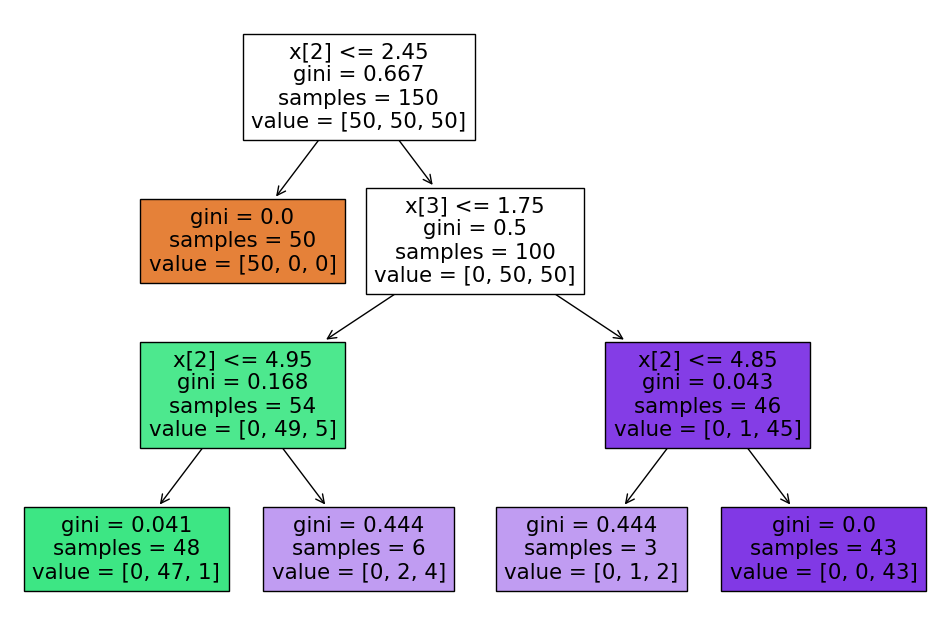

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    tree,
    filled=True
)

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

tree = DecisionTreeClassifier(criterion="gini", random_state=42)

tree.fit(X,y)

print(tree.score(X,y))

1.0


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

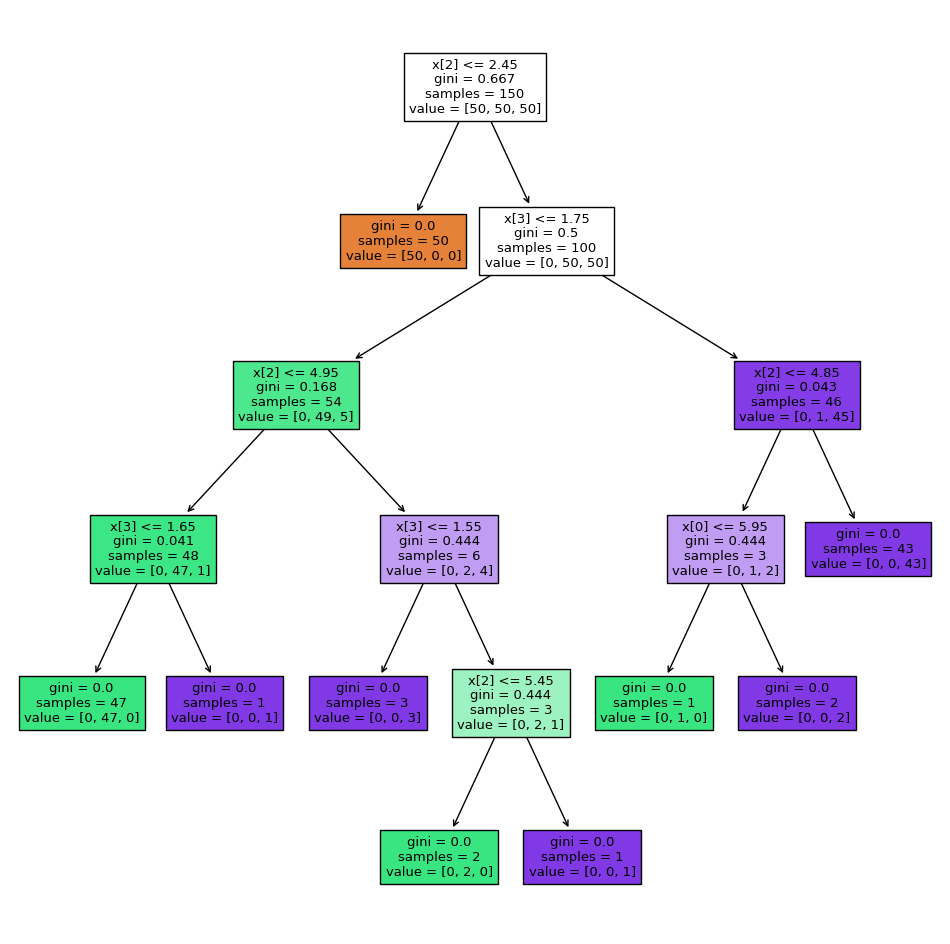

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

plot_tree(tree, filled=True)

plt.show()

gini - 2 category - 0 - 0.5
gini - 3 catgeory - 0 - 0.66

entropy - 2 category - 0 - 1
entropy - 3 category - 0 - 1.5